# `0.bell` — Bell state on the MLIR stack

This is the MLIR-stack counterpart of [examples/0.bell.ipynb](../../examples/0.bell.ipynb).

The original notebook used the **toy** ISA (`mix` / `entangle`). The toy
dialect has not been ported yet (see Phase 4.1 of the plan), so here we
build the same Bell state directly out of Cliffords (`h` + `cx`).

In [1]:
%load_ext qstack_mlir.jupyter

## 1. Source program

A two-qubit register, a Hadamard on `q[0]`, a `cx` from `q[0]` to
`q[1]`, then measure both. The result should be a uniform mixture of
`00` and `11`.

In [2]:
%%qasm bell
QSTACKQASM 0.1;
include "qstack/cliffords.inc";

qreg q[2];
creg c[2];
h q[0];
cx q[0], q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];

<ModuleOp 4686010976(operands=[], results=[], successors=[], properties={}, attributes={}, regions=[<Region 4685619680>], parent=None, _next_op=None, _prev_op=None)>

## 2. Inspect the lowered IR

The surface program lowers to a single `qstack.kernel` whose body
applies the Cliffords, measures both qubits, and returns the two bits
through the kernel boundary.

In [3]:
print(bell)

builtin.module {
  func.func @main() -> (!qstack.bit, !qstack.bit) {
    %0, %1 = qstack.kernel {
    ^bb0(%2: !qstack.qubit, %3: !qstack.qubit):
      %4 = "cliffords.h"(%2) : (!qstack.qubit) -> !qstack.qubit
      %5, %6 = "cliffords.cx"(%4, %3) : (!qstack.qubit, !qstack.qubit) -> (!qstack.qubit, !qstack.qubit)
      %7 = qstack.measure %5
      %8 = qstack.measure %6
      qstack.return %7, %8 : !qstack.bit, !qstack.bit
    } : () -> !qstack.bit, !qstack.bit
    func.return %0, %1 : !qstack.bit, !qstack.bit
  }
}


## 3. Run on the emulator

No host-side callbacks are needed (no `select` / `decode` ops), so we
hand the `Machine` an empty `CallbackRegistry`.

In [4]:
from qstack_mlir.runtime import CallbackRegistry, Machine

machine = Machine(bell, num_qubits=4, registry=CallbackRegistry())
results = machine.shots("main", 2000)
results

Results(2000 shots, histogram={(0, 0): 1005, (1, 1): 995})

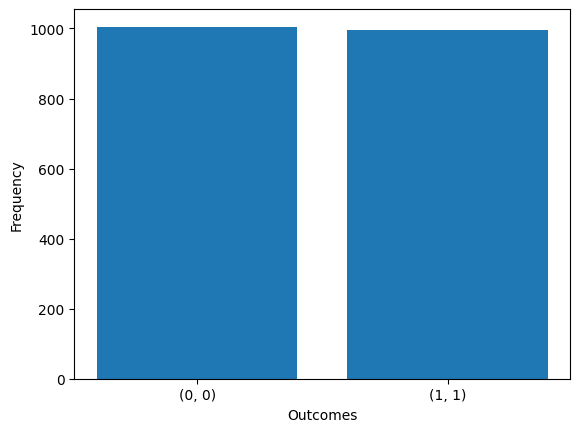

<Axes: xlabel='Outcomes', ylabel='Frequency'>

In [5]:
results.plot_histogram()

The histogram concentrates on `(0, 0)` and `(1, 1)` in roughly equal
proportions — the signature of the Bell state $\tfrac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$.